# 1. Experiment Introduction

## 1.1 Experiment Objectives

(1) Deeply understand the meaning of machine learning and the basic workflow for solving machine learning tasks;

(2) Learn to use Python programming language and machine learning libraries (e.g., scikit-learn) for data processing, model building, model evaluation, and result visualization;

(3) Understand the basic concepts and principles of K-means clustering model;

(4) Understand the evaluation metrics for K-means clustering model (Silhouette Score, Adjusted Rand Index);

(5) Master how to use K-means model to solve clustering tasks in machine learning.

## 1.2 Experiment Content

This experiment belongs to the cross-disciplinary analysis of tea science and machine learning. Different tea varieties have differences in their flavor substances. The flavor substance dataset used in this experiment contains data on the main flavor substance contents of different tea varieties. The data information is as follows:

<span style="color: red;">
<ul>
  <li><strong>Column 1 (target):</strong> `tea_type` (茶叶品种)</li>
  <li><strong>Column 2:</strong> `hexanal` (己醛)</li>
  <li><strong>Column 3:</strong> `pentanoic acid` (戊酸)</li>
  <li><strong>Column 4:</strong> `hexanoic acid` (己酸)</li>
  <li><strong>Column 5:</strong> `propanoic acid` (丙酸)</li>
  <li><strong>Column 6:</strong> `2-pentylfuran` (2-戊基呋喃)</li>
  <li><strong>Column 7:</strong> `benzyl alcohol` (苯甲醇)</li>
  <li><strong>Column 8:</strong> `acetic acid` (乙酸)</li>
  <li><strong>Column 9:</strong> `furfural` (糠醛)</li>
  <li><strong>Column 10:</strong> `2-phenylethanol` (2-苯乙醇)</li>
</ul>
</span>

## 1.3 Experiment Principle

Clustering is an unsupervised learning method that aims to partition samples in a dataset into several clusters, such that samples within the same cluster are similar, while samples from different clusters are significantly different. Common clustering algorithms include K-means, hierarchical clustering, and DBSCAN. In this experiment, we will use the K-means algorithm for clustering analysis.

<font color="red">
The basic idea of the K-means algorithm is as follows:

(1) Randomly select K initial cluster centers.

(2) Assign each sample to the nearest cluster center.

(3) Recompute the center point of each cluster.

(4) Repeat steps 2 and 3 until the cluster centers no longer change or change very little.
</font>
In this experiment, the flavor substance content is used as the input feature, and the tea type is the output target. A K-means clustering model is built and trained on the training data, and its prediction performance is validated on the test set.

## 1.4 Experiment Environment

- Python 3.10.16
- numpy 1.26.4
- pandas 2.2.3
- matplotlib 3.10.0
- scikit-learn 1.6.1

## 1.5 Experiment Steps

<font color="red">
    
(1) Load data

(2) Separate feature variables (X) and target variable (y) – features are Column 2 to Column 10, target is Column 1 (`tea_type`)

(3) Split dataset: training set (**80%**) and test set (**20%**)

(4) Data preprocessing – feature standardization (**StandardScaler**), dimension reduction (**PCA**)

(5) Build and train k-means model (**set n_clusters**)

(6) Test and evaluate the machine learning model (**e.g., silhouette score, adjusted rand index**)

(7) Visualize experimental results

</font>

---

# 2. Experiment Requirements

## 2.1 Data and Result Visualization

<span style="color: red;">
<ul>
  <li>Draw a scatter plot of the training set after dimensionality reduction (2D).</li>
  <li>Draw the clustering result plot for the training set (showing centroids).</li>
  <li>Draw the WCSS elbow curve and the silhouette coefficient curve, showing the variation of both metrics for the number of clusters from 2 to 10, and indicate the optimal number of clusters.</li>
</ul>
</span>


In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

csv_candidates = [
    Path("tea_chemical_data.csv"),
    Path("PJJ/Lab08/tea_chemical_data.csv"),
    Path.cwd() / "tea_chemical_data.csv",
    Path.cwd() / "PJJ/Lab08/tea_chemical_data.csv",
]
for candidate in csv_candidates:
    if candidate.exists():
        csv_path = candidate
        break
else:
    raise FileNotFoundError("Cannot find tea_chemical_data.csv in the notebook directory or workspace root.")

df = pd.read_csv(csv_path)
print(f"Loaded dataset from: {csv_path}")
print(df.shape)
df.head()

Loaded dataset from: tea_chemical_data.csv
(1000, 10)


,tea_type,hexanal,pentanoic acid,hexanoic acid,propanoic acid,2-pentylfuran,benzyl alchol,acetic acid,furfural,2-phenylethanol
0,black tea,1.24,1.57,0.96,3.32,0.52,1.11,23.95,3.54,0.77
1,dark tea,0.82,1.88,1.07,3.34,0.52,0.53,23.59,3.49,0.59
2,oolong tea,1.27,0.90,0.73,1.44,0.41,1.64,10.55,2.03,1.37
3,white tea,0.44,0.67,0.23,0.74,0.29,1.15,4.18,0.99,0.94
4,green tea,1.35,0.31,0.27,1.18,0.31,0.88,3.88,0.51,0.48


In [18]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0].astype(str)

feature_names = X.columns.tolist()
class_names = sorted(y.unique().tolist())

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Classes: {class_names}")

Feature matrix shape: (1000, 9)
Target vector shape: (1000,)
Classes: ['black tea', 'dark tea', 'green tea', 'oolong tea', 'white tea']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (800, 9), (800,)
Test set: (200, 9), (200,)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization complete.")

Standardization complete.


Explained variance ratio: 0.8225


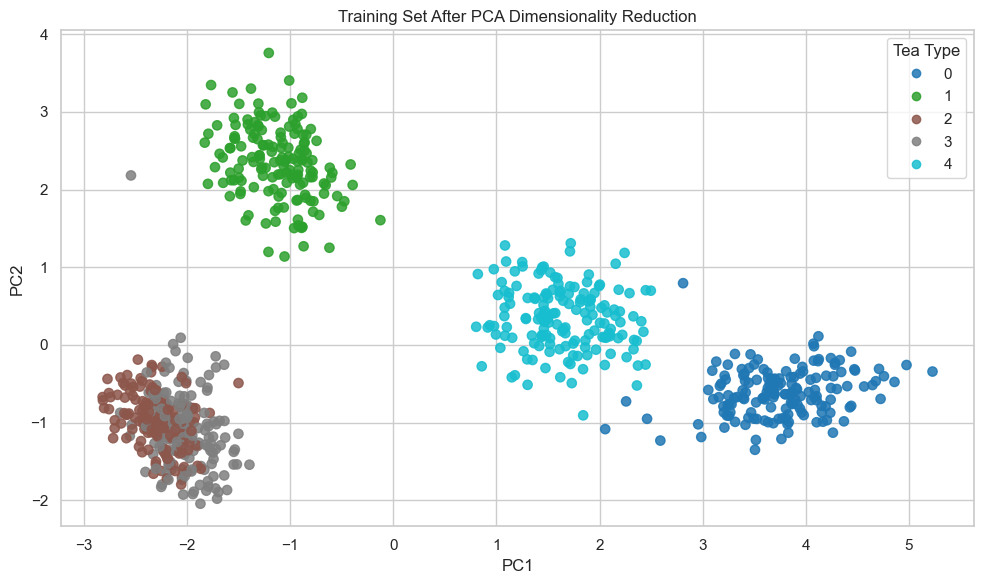

In [21]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

train_pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
train_pca_df["tea_type"] = y_train.to_numpy()

print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    train_pca_df["PC1"],
    train_pca_df["PC2"],
    c=pd.factorize(train_pca_df["tea_type"])[0],
    cmap="tab10",
    s=45,
    alpha=0.85,
)
plt.title("Training Set After PCA Dimensionality Reduction")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Tea Type", loc="best")
plt.tight_layout()
plt.show()

In [22]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
kmeans.fit(X_train_scaled)

print(f"KMeans model trained with n_clusters={n_clusters}")

KMeans model trained with n_clusters=5


In [23]:
train_cluster_labels = kmeans.labels_

print("Training cluster label counts:")
for cluster_id in range(n_clusters):
    count = int(np.sum(train_cluster_labels == cluster_id))
    print(f"Cluster {cluster_id}: {count}")

Training cluster label counts:
Cluster 0: 161
Cluster 1: 158
Cluster 2: 160
Cluster 3: 162
Cluster 4: 159


In [24]:
train_silhouette = silhouette_score(X_train_scaled, train_cluster_labels)
train_ari = adjusted_rand_score(y_train, train_cluster_labels)

print(f"Training Silhouette Score: {train_silhouette:.4f}")
print(f"Training Adjusted Rand Index: {train_ari:.4f}")

Training Silhouette Score: 0.5060
Training Adjusted Rand Index: 0.9906


In [25]:
test_cluster_labels = kmeans.predict(X_test_scaled)
test_silhouette = silhouette_score(X_test_scaled, test_cluster_labels)
test_ari = adjusted_rand_score(y_test, test_cluster_labels)

print(f"Test Silhouette Score: {test_silhouette:.4f}")
print(f"Test Adjusted Rand Index: {test_ari:.4f}")

Test Silhouette Score: 0.4798
Test Adjusted Rand Index: 0.9874


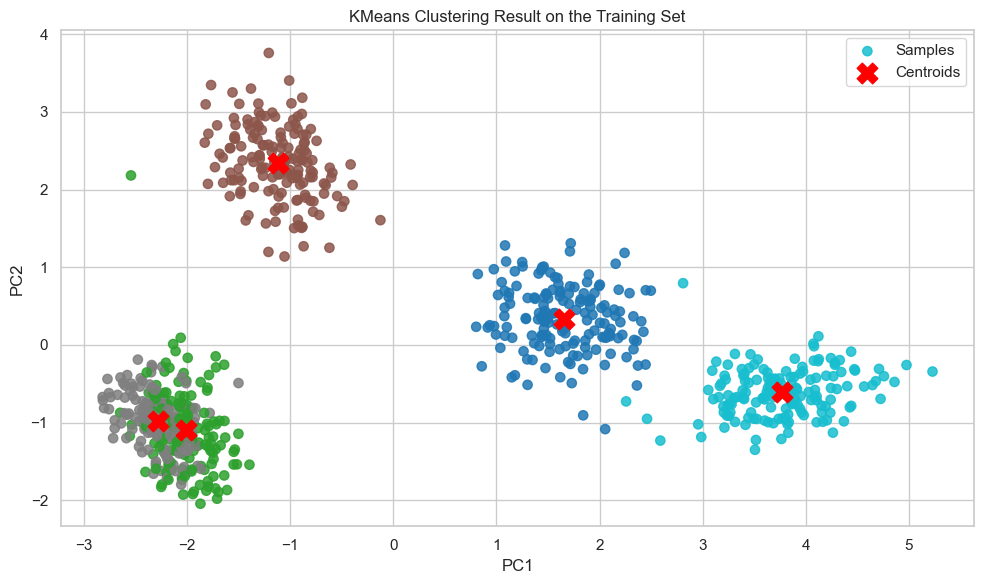

In [26]:
def plot_cluster_result(model, title):
    cluster_labels = model.labels_
    centers_pca = pca.transform(model.cluster_centers_)

    plt.figure(figsize=(10, 6))
    plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=cluster_labels,
        cmap="tab10",
        s=45,
        alpha=0.85,
        label="Samples",
    )
    plt.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        c="red",
        marker="X",
        s=220,
        label="Centroids",
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_cluster_result(kmeans, "KMeans Clustering Result on the Training Set")

In [27]:
cluster_range = range(2, 11)
inertias = []
silhouette_values = []

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_train_scaled)
    inertias.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_train_scaled, labels))

optimal_k = list(cluster_range)[int(np.argmax(silhouette_values))]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

Optimal number of clusters based on silhouette score: 4


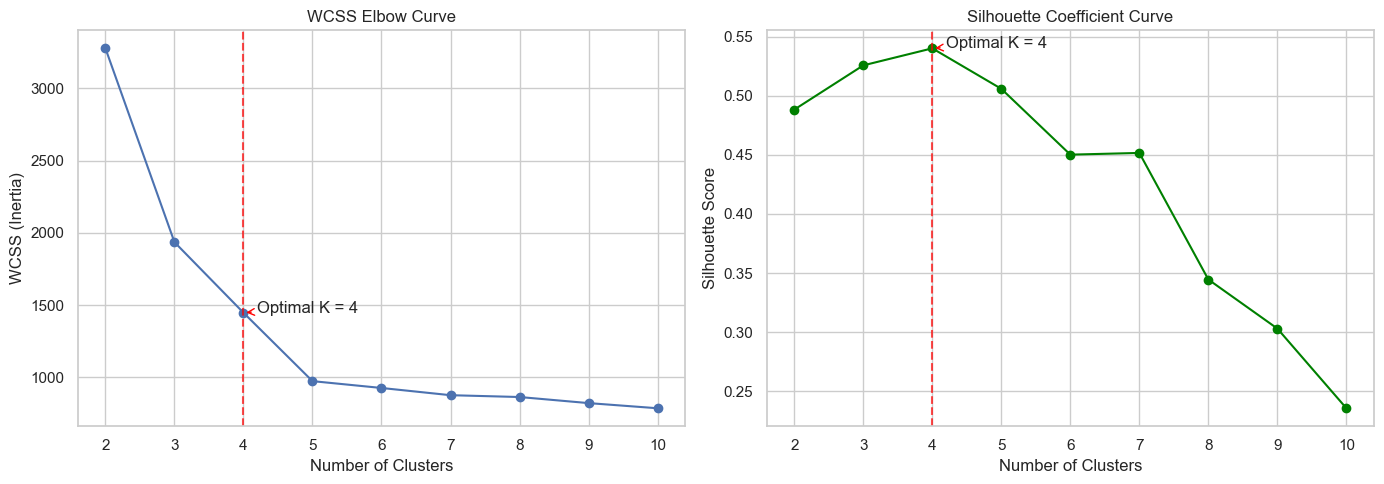

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(cluster_range), inertias, marker="o")
axes[0].set_title("WCSS Elbow Curve")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].axvline(optimal_k, color="red", linestyle="--", alpha=0.7)
axes[0].annotate(
    f"Optimal K = {optimal_k}",
    xy=(optimal_k, inertias[optimal_k - 2]),
    xytext=(optimal_k + 0.2, inertias[optimal_k - 2]),
    arrowprops=dict(arrowstyle="->", color="red"),
)

axes[1].plot(list(cluster_range), silhouette_values, marker="o", color="green")
axes[1].set_title("Silhouette Coefficient Curve")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(optimal_k, color="red", linestyle="--", alpha=0.7)
axes[1].annotate(
    f"Optimal K = {optimal_k}",
    xy=(optimal_k, silhouette_values[optimal_k - 2]),
    xytext=(optimal_k + 0.2, silhouette_values[optimal_k - 2]),
    arrowprops=dict(arrowstyle="->", color="red"),
)

plt.tight_layout()
plt.show()

The current model is not optimal, so the model is retrained with the optimal number of clusters.
Final Training Silhouette Score: 0.5403
Final Training Adjusted Rand Index: 0.7763
Final Test Silhouette Score: 0.5336
Final Test Adjusted Rand Index: 0.7791


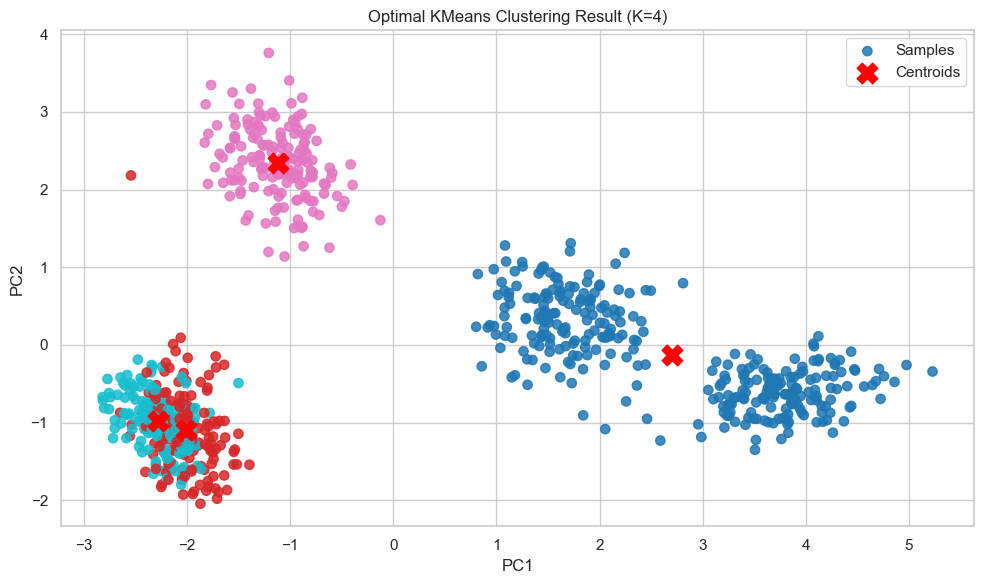

Conclusion: the silhouette-based optimal cluster count is 4, and the baseline model uses 5.


In [29]:
if optimal_k != n_clusters:
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
    final_kmeans.fit(X_train_scaled)
    final_train_labels = final_kmeans.labels_
    final_test_labels = final_kmeans.predict(X_test_scaled)

    final_train_silhouette = silhouette_score(X_train_scaled, final_train_labels)
    final_train_ari = adjusted_rand_score(y_train, final_train_labels)
    final_test_silhouette = silhouette_score(X_test_scaled, final_test_labels)
    final_test_ari = adjusted_rand_score(y_test, final_test_labels)

    print("The current model is not optimal, so the model is retrained with the optimal number of clusters.")
    print(f"Final Training Silhouette Score: {final_train_silhouette:.4f}")
    print(f"Final Training Adjusted Rand Index: {final_train_ari:.4f}")
    print(f"Final Test Silhouette Score: {final_test_silhouette:.4f}")
    print(f"Final Test Adjusted Rand Index: {final_test_ari:.4f}")
    plot_cluster_result(final_kmeans, f"Optimal KMeans Clustering Result (K={optimal_k})")
else:
    print("The current model already uses the optimal number of clusters.")

print(f"Conclusion: the silhouette-based optimal cluster count is {optimal_k}, and the baseline model uses {n_clusters}.")